Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [14]:

library(tidymodels)


The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [15]:
 library(tidymodels)
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [16]:

glimpse(diabetes_train)

Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 5, 10, 4, 3, 1, 13, 3, 10, 4, 11, 3, 7, 7,…
$ Glucose                  <dbl> 89, 116, 115, 110, 126, 97, 145, 88, 122, 103…
$ BloodPressure            <dbl> 66, 74, 0, 92, 88, 66, 82, 58, 78, 60, 76, 64…
$ SkinThickness            <dbl> 23, 0, 0, 0, 41, 15, 19, 11, 31, 33, 0, 25, 1…
$ Insulin                  <dbl> 94, 0, 0, 0, 235, 140, 110, 54, 0, 192, 0, 70…
$ BMI                      <dbl> 28.1, 25.6, 35.3, 37.6, 39.3, 23.2, 22.2, 24.…
$ DiabetesPedigreeFunction <dbl> 0.167, 0.201, 0.134, 0.191, 0.704, 0.487, 0.2…
$ Age                      <dbl> 21, 30, 29, 30, 27, 22, 57, 22, 45, 33, 35, 2…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

Outcome is suitable as the outcome variable in a logistic regression model because it is a binary categorical variable.

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     |  Plasma glucose concentration 2 hours after an oral glucose tolerance test (mg/dL) |           
| BMI         |  Body Mass Index (weight in kg / height in m²) |           

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

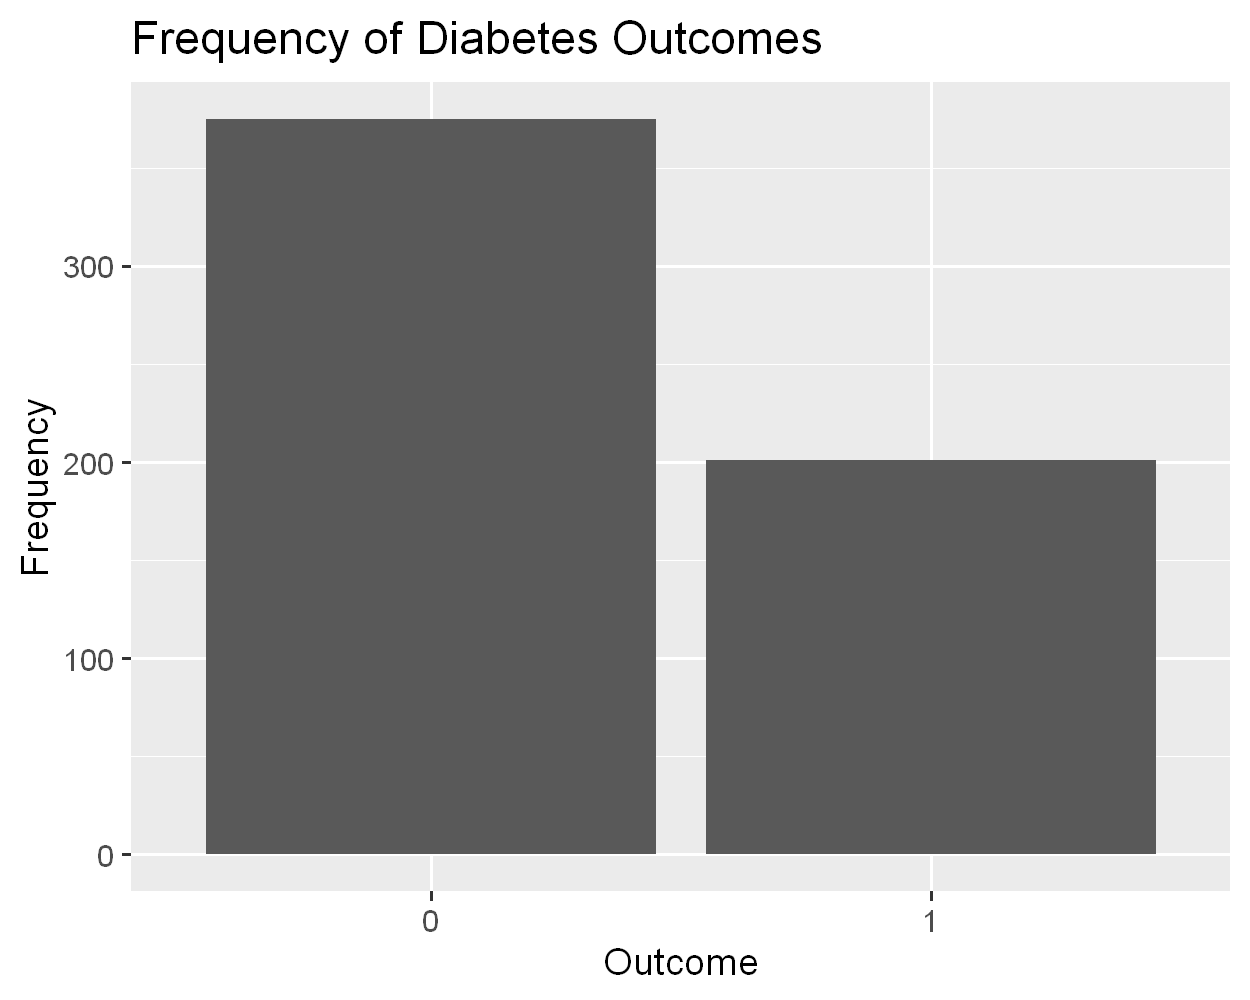

In [20]:
ggplot(diabetes_train, aes(x = Outcome)) +
  geom_bar() +
  labs(
    title = "Frequency of Diabetes Outcomes",
    x = "Outcome",
    y = "Frequency"
  )
           

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**

No, the data is not balanced. There are more observations with Outcome = 0 than Outcome = 1.



Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [21]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,89.0
0,BMI,28.1
0,Glucose,116.0
0,BMI,25.6
0,Glucose,115.0
0,BMI,35.3


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

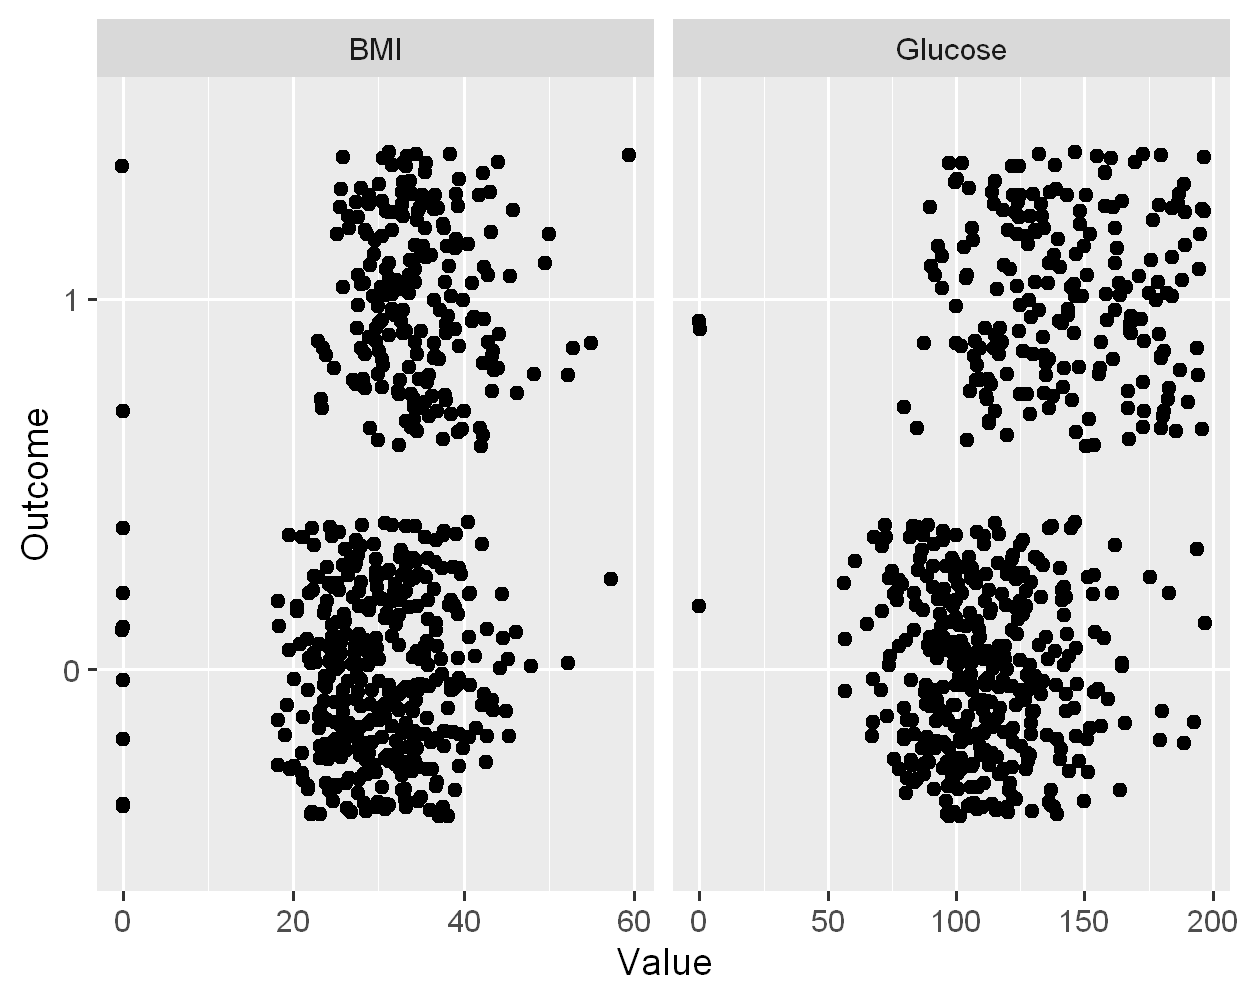

In [22]:

ggplot(plot_df, aes(x = value, y = Outcome)) +
  geom_jitter() +
  facet_wrap(~name, ncol = 2, scales = "free_x") +
  labs(
    x = "Value",
    y = "Outcome"
  )


❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

The x-axis scale is shared between the two plots, which makes the BMI distribution harder to see because Glucose has a much larger range.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [26]:
logistic_model <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")

logistic_fit <- logistic_model |>
  fit(Outcome ~ BMI + Glucose, data = diabetes_train)

logistic_fit

parsnip model object


Call:  stats::glm(formula = Outcome ~ BMI + Glucose, family = stats::binomial, 
    data = data)

Coefficients:
(Intercept)          BMI      Glucose  
   -7.11073      0.06844      0.03423  

Degrees of Freedom: 575 Total (i.e. Null);  573 Residual
Null Deviance:	    745.1 
Residual Deviance: 589.3 	AIC: 595.3

Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [29]:
diabetes_test_wPred <- augment(logistic_fit, new_data = diabetes_test)
glimpse(diabetes_test_wPred)


Rows: 192
Columns: 12
$ .pred_class              <fct> 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, …
$ .pred_0                  <dbl> 0.9153437, 0.9104500, 0.1518960, 0.6220239, 0…
$ .pred_1                  <dbl> 0.084656330, 0.089549997, 0.848103987, 0.3779…
$ Pregnancies              <dbl> 1, 3, 2, 10, 1, 1, 8, 10, 5, 5, 3, 6, 4, 7, 1…
$ Glucose                  <dbl> 85, 78, 197, 139, 103, 115, 99, 125, 117, 109…
$ BloodPressure            <dbl> 66, 50, 70, 80, 30, 70, 84, 70, 92, 75, 76, 9…
$ SkinThickness            <dbl> 29, 32, 45, 0, 38, 30, 0, 26, 0, 26, 36, 0, 4…
$ Insulin                  <dbl> 0, 88, 543, 0, 83, 96, 0, 115, 0, 0, 245, 0, …
$ BMI                      <dbl> 26.6, 31.0, 30.5, 27.1, 43.3, 34.6, 35.4, 31.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.248, 0.158, 1.441, 0.183, 0.529, 0.3…
$ Age                      <dbl> 31, 26, 53, 57, 33, 32, 50, 41, 38, 60, 28, 2…
$ Outcome                  <fct> 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, …


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [31]:
mod_fit <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification") |>
  fit(Outcome ~ BMI + Glucose, data = diabetes_train)
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 111  29
         1  14  38

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

How many individuals had diabetes in the test data?
67 individuals (29 + 38).
Of those that actually had diabetes, how many were predicted to have diabetes?
38 individuals.
How many individuals predicted to have diabetes did not have diabetes?
14 individuals.